# Churn Prediction

**Dataset Description**: Churn prediction is the process of analyzing customer behavior to predict when a customer will stop using a product or service. It's a data-driven process that uses historical data, behavioral analytics, and machine learning algorithms to identify customers who are likely to churn.

**About Dataset/Content**: This data set is highly imbalanced and contains details of a bank's customers and the target variable is a binary variable reflecting the fact whether the customer left the bank (closed his account) or he continues to be a customer.


## Imports

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier, plot_tree
# from pgmpy.models import BayesianNetwork
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

## Data Preprocessing

Explained Variance Ratio for each Principal Component:

Component 1: 14.48%
Component 2: 11.20%
Component 3: 9.96%
Component 4: 9.31%
Component 5: 9.26%
Component 6: 9.06%
Component 7: 8.88%
Component 8: 8.75%
Component 9: 8.60%
Component 10: 5.60%

PCA captures 95.10% of the variance with 10 components.


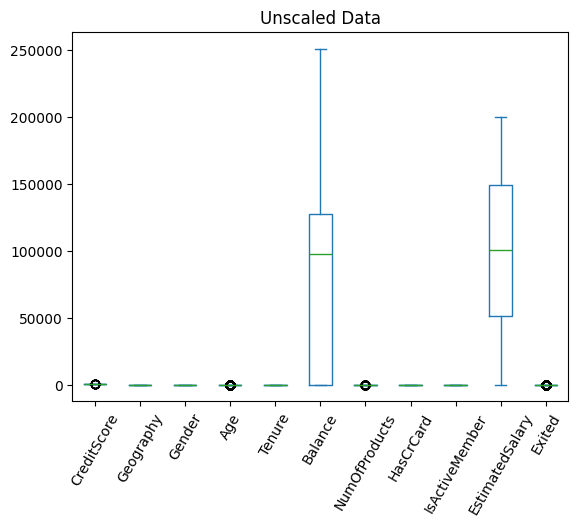

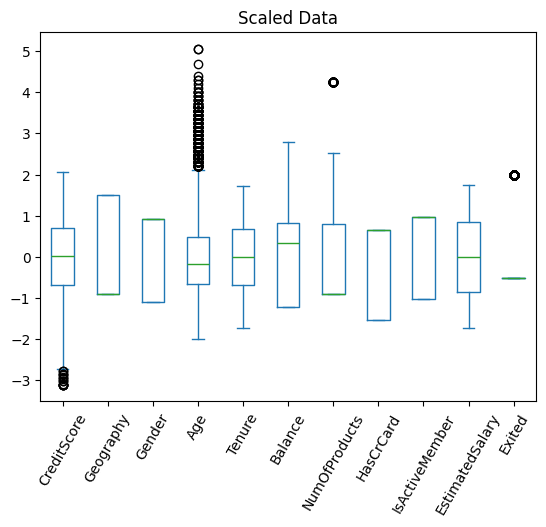

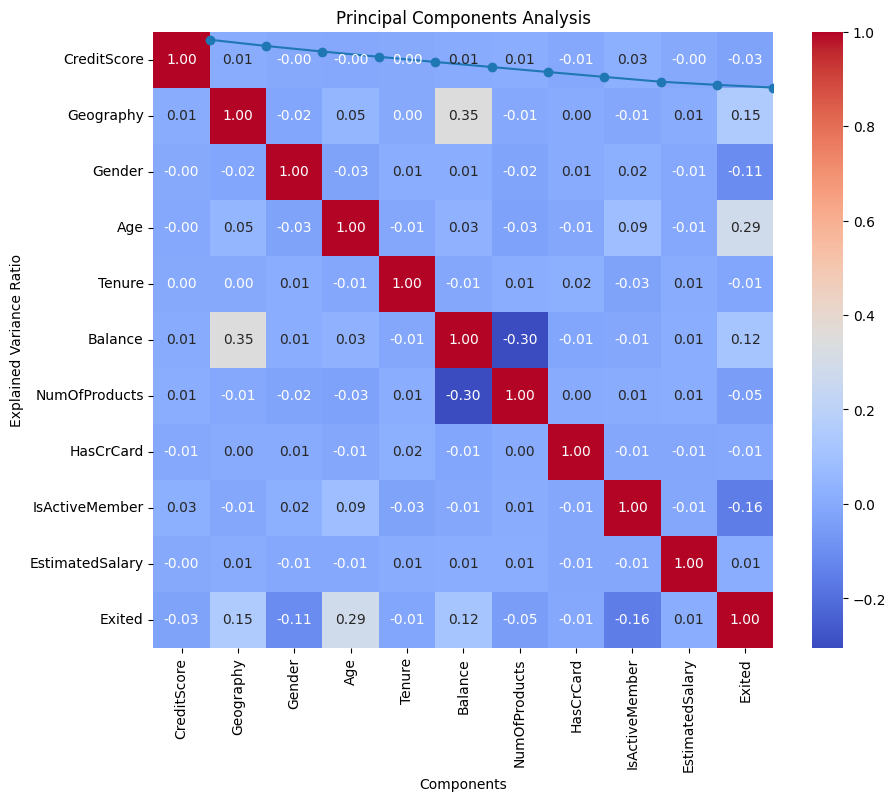

In [9]:
# TODO: Consider the removal of the Country label
DATA_FILE_NAME = "Churn_Modelling.csv"
TARGET_COLUMN_NAME = "Exited"
IRRELEVANT_COLUMN_NAMES = ["RowNumber", "CustomerId", "Surname"]
NON_NUMERIC_COLUMN_NAMES = ["Gender", "Geography"]


def enumerate_categorical_data(data_frame, feature_name):
    """ Convert categorical data to numerical. """
    # Track unique values in a column
    value_map = {}
    assigned_number = 0

    # Build a dictionary mapping a column's unique values to numbers
    column = data_frame[feature_name]
    for value in column:
        if value not in value_map:
            value_map[value] = assigned_number
            assigned_number += 1

    # Map column's data to numbers
    # Example: feature_name = Gender, Male becomes 0, Female becomes 1
    data_frame[feature_name] = data_frame[feature_name].map(value_map)

def box_plot_frame(data_frame, title=""):
    data_frame.plot(kind="box")
    plt.title(title)
    plt.xticks(rotation=60)
    #plt.show()

def correlation_plot_frame(data_frame):
    """Generates """
    correlation_matrix = data_frame.corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    #plt.show()

def analyze_components(data_frame):
    threshold = 0.95

    component_analysis = PCA()
    component_analysis.fit(data_frame)    
    
    def components_to_retain(explained_variance_ratio, threshold):
        cumulative_variance_sums = np.cumsum(explained_variance_ratio)
        
        component_count = len(cumulative_variance_sums)
        for i in range(len(cumulative_variance_sums)):     
            if threshold <= cumulative_variance_sums[i]:   
                component_count = i + 1                    
                break                                      
                
        return component_count   
    
    component_counts = [i for i in range(1, len(np.cumsum(component_analysis.explained_variance_ratio_)) + 1)]
    summed_explained_variance_ratios = np.cumsum(component_analysis.explained_variance_ratio_)
    plt.plot(component_counts, summed_explained_variance_ratios, "-o")
    plt.title("Principal Components Analysis")
    plt.xlabel("Components")
    plt.ylabel("Explained Variance Ratio")
    #plt.show()
    
    component_count = components_to_retain(component_analysis.explained_variance_ratio_, threshold)   

    n_components_analysis = PCA(n_components=component_count)   
    n_components_analysis.fit(data_frame)   
    
    print("Explained Variance Ratio for each Principal Component:\n")
    for i in range(len(n_components_analysis.explained_variance_ratio_)):    
        print(f"Component {i + 1}: {n_components_analysis.explained_variance_ratio_[i] * 100:.2f}%")

    print("\nPCA captures {:.2f}% of the variance with {} components.".format(sum(n_components_analysis.explained_variance_ratio_) * 100, component_count)) 

# Start Data Preprocessing
data_frame = pd.read_csv(DATA_FILE_NAME)
data_frame = data_frame.drop(columns=IRRELEVANT_COLUMN_NAMES)

feature_names = data_frame.columns.values # [feature_name for feature_name in data_frame]

for column_name in NON_NUMERIC_COLUMN_NAMES:
    enumerate_categorical_data(data_frame, column_name)

box_plot_frame(data_frame, "Unscaled Data")

scaler = StandardScaler()
scaled_data = scaler.fit_transform(data_frame)

data_frame = pd.DataFrame(data=scaled_data, columns=feature_names)

box_plot_frame(data_frame, "Scaled Data")

correlation_plot_frame(data_frame)

analyze_components(data_frame)

x = data_frame.drop(columns=[TARGET_COLUMN_NAME])
y = data_frame[TARGET_COLUMN_NAME]

## Model Design and Training

Decision tree test accuracies 79.45% for Max Depth of 1
Decision tree test accuracies 84.08% for Max Depth of 2
Decision tree test accuracies 83.64% for Max Depth of 3
Decision tree test accuracies 84.29% for Max Depth of 4
Decision tree test accuracies 83.84% for Max Depth of 5
Decision tree test accuracies 84.12% for Max Depth of 6
Decision tree test accuracies 83.79% for Max Depth of 7
Decision tree test accuracies 82.91% for Max Depth of 8
Decision tree test accuracies 82.51% for Max Depth of 9
Decision tree test accuracies 81.45% for Max Depth of 10
Decision tree test accuracies 80.06% for Max Depth of 11
Decision tree test accuracies 79.80% for Max Depth of 12
Decision tree test accuracies 79.25% for Max Depth of 13
Decision tree test accuracies 78.84% for Max Depth of 14
Decision tree test accuracies 78.06% for Max Depth of 15
Decision tree test accuracies 77.42% for Max Depth of 16
Decision tree test accuracies 77.89% for Max Depth of 17
Decision tree test accuracies 77.81% for

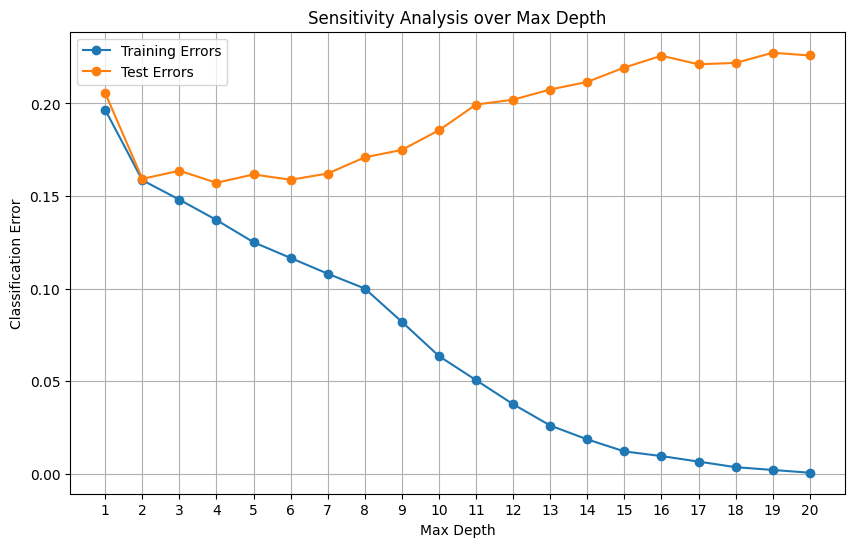

Default Gaussian Naive Bayes Test Accuracy: 82.99%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.1) Test Accuracy: 82.91%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.2) Test Accuracy: 82.42%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.3) Test Accuracy: 81.94%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.4) Test Accuracy: 81.46%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.5) Test Accuracy: 81.10%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.6) Test Accuracy: 80.77%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.7) Test Accuracy: 80.59%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.8) Test Accuracy: 80.34%
Improved Gaussian Naive Bayes (w/ var_smooth of 0.9) Test Accuracy: 80.14%
Improved Gaussian Naive Bayes (w/ var_smooth of 1.0) Test Accuracy: 80.05%
Linear SVM Accuracy: 79.45%

Poly SVM Accuracy: 84.50%

Rbf SVM Accuracy: 84.94%

Sigmoid SVM Accuracy: 74.19%

Best Parameters: {'C': 100, 'gamma': 0.01}
SVM Accuracy with Best Parameters for RBF: 8

In [10]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, train_size=0.2)

# Initializes object to be used to remove the mean and scale data to unit variance
sc = StandardScaler()
# Fits the data using the calculated mean and std and standardizes X_train and X_test by via transform
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Discretizes data to prevent ValueError with classifier
y_train = [ int(y) for y in y_train ]
y_test = [ int(y) for y in y_test ]


# Tests accuracy of testing sample with varying max depth values for Decision Tree classifier
max_depth_values = range(1, 21)  # Test max_depth from 1 to 20
# Initialize lists to store training and test errors
training_errors = []
test_errors = []

for max_depth in max_depth_values:
    # Train a decision tree classifier with the current max_depth value
    tree_model = DecisionTreeClassifier(max_depth=max_depth, random_state=0)
    tree_model.fit(x_train, y_train)

    # Evaluate the classifier on the training set
    y_train_pred = tree_model.predict(x_train)
    train_score = accuracy_score(y_train, y_train_pred)
    training_errors.append(1 - train_score)

    # Evaluate the classifier on the test set
    y_test_pred = tree_model.predict(x_test)
    test_score = accuracy_score(y_test, y_test_pred)
    test_errors.append(1 - test_score)
    print(f'Decision tree test accuracies {test_score:.2%} for Max Depth of {max_depth}')

# Plot the sensitivity analysis results
plt.figure(figsize=(10, 6))
plt.clf()
plt.plot(max_depth_values, training_errors, marker='o', label='Training Errors')
plt.plot(max_depth_values, test_errors, marker='o', label='Test Errors')
plt.title('Sensitivity Analysis over Max Depth')
plt.xlabel('Max Depth')
plt.ylabel('Classification Error')
plt.xticks(max_depth_values)
plt.grid(True)
plt.legend()
plt.show()


# Tests accuracy of testing sample with default Gaussian Naive
gnb = GaussianNB()
gnb.fit(x_train, y_train)
y_test_pred = gnb.predict(x_test)
testing_accuracy = accuracy_score(y_test, y_test_pred)
print(f'Default Gaussian Naive Bayes Test Accuracy: {testing_accuracy:.2%}')

percentile = 0.1

# Tests Gaussian Naive with various var_smoothing values
while percentile <= 1:
    gnb = GaussianNB(var_smoothing = percentile)
    gnb.fit(x_train, y_train)
    y_test_pred = gnb.predict(x_test)
    testing_accuracy = accuracy_score(y_test, y_test_pred)
    print(f'Improved Gaussian Naive Bayes (w/ var_smooth of {percentile:.1f}) Test Accuracy: {testing_accuracy:.2%}')
    percentile += 0.1


# Trains SVC models based on different kernels and tests the accuracy of each regarding the testing sample
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
for kernel in kernels:
    svm = SVC(kernel=kernel, C=1.0, random_state=1)
    y_pred = svm.fit(x_train, y_train).predict(x_test)
    kernel_svm_accuracy = accuracy_score(y_test, y_pred)
    print(f'{kernel.capitalize()} SVM Accuracy: {kernel_svm_accuracy:.2%}\n')

# Task 4: Hyperparameter Tuning : Use GridSearchCV to find the best hyperparameters and print them out
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [1, 0.1, 0.01, 0.001]}
svm_classifier = SVC(kernel='rbf')
grid_search = GridSearchCV(estimator=svm_classifier, param_grid=param_grid)
        
# Carries out a hyperparameter search in order to infer the best combination of parameters for the given SVC model
grid_search = grid_search.fit(x_train, y_train)
print(f'Best Parameters: {grid_search.best_params_}')

# Trains an SVM model with and tests its accuracy
svm_with_best_params = SVC(kernel='rbf', C=10, gamma=0.1, random_state=1)
y_pred = svm_with_best_params.fit(x_train, y_train).predict(x_test)
best_params_svm_accuracy = accuracy_score(y_test, y_pred)
print(f'SVM Accuracy with Best Parameters for RBF: {best_params_svm_accuracy:.2%}')